# Inversi Resistivitas Well Logging Menggunakan Grid Search dan PSO

Notebook ini dibuat mengikuti struktur esai:
- Forward Model
- Data Observasi
- Noise
- Misfit Function
- Grid Search
- Particle Swarm Optimization (PSO)
- Perbandingan hasil
- Interpretasi geologi


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
import time

np.random.seed(42)


## Model Sintetik (Ground Truth)

In [2]:
true_model = {
    'rho1':15,
    'h1':10,
    'rho2':3,
    'h2':25,
    'rho3':125,
    'h3':40,
    'rho4':500
}

depth = np.arange(0,100,1)


## Forward Model 1D Layered Earth

In [3]:
def forward_model(model, depth):

    rho1,h1,rho2,h2,rho3,h3,rho4 = model

    rho = np.zeros_like(depth,dtype=float)

    for i,z in enumerate(depth):

        if z < h1:
            rho[i] = rho1

        elif z < h1+h2:
            rho[i] = rho2

        elif z < h1+h2+h3:
            rho[i] = rho3

        else:
            rho[i] = rho4

    return rho


## Generate Data Observasi + Noise

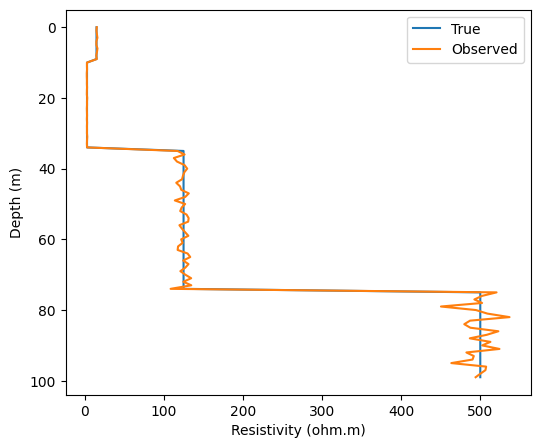

In [4]:
m_true = [
    true_model['rho1'],
    true_model['h1'],
    true_model['rho2'],
    true_model['h2'],
    true_model['rho3'],
    true_model['h3'],
    true_model['rho4']
]

d_true = forward_model(m_true,depth)

noise_percent = 0.05

noise = np.random.normal(
    0,
    noise_percent*d_true
)

d_obs = d_true + noise

plt.figure(figsize=(6,5))
plt.plot(d_true,depth,label='True')
plt.plot(d_obs,depth,label='Observed')
plt.gca().invert_yaxis()
plt.legend()
plt.xlabel('Resistivity (ohm.m)')
plt.ylabel('Depth (m)')
plt.show()


## Misfit Function

In [5]:
sigma = noise_percent*np.maximum(d_obs,1)

def misfit(model):

    d_calc = forward_model(model,depth)

    E = np.sum(
        ((d_obs-d_calc)/sigma)**2
    )

    return E


## Grid Search

In [6]:
rho1_range = np.linspace(5,30,30)
h1_range = np.linspace(5,20,30)

best_model_grid = None
best_misfit_grid = np.inf

t0 = time.time()

for rho1,h1 in product(rho1_range,h1_range):

    model = [
        rho1,
        h1,
        3,
        25,
        125,
        40,
        500
    ]

    E = misfit(model)

    if E < best_misfit_grid:

        best_misfit_grid = E
        best_model_grid = model

grid_time = time.time()-t0

print(best_model_grid)
print(best_misfit_grid)
print(grid_time)


[np.float64(15.344827586206897), np.float64(9.137931034482758), 3, 25, 125, 40, 500]
86.68027637597054
0.06918144226074219


## Misfit Surface

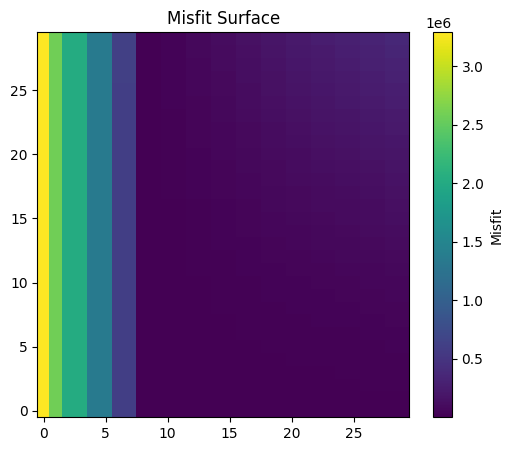

In [7]:
surface = np.zeros(
    (len(rho1_range),len(h1_range))
)

for i,r1 in enumerate(rho1_range):

    for j,h1 in enumerate(h1_range):

        surface[i,j] = misfit(
            [r1,h1,3,25,125,40,500]
        )

plt.figure(figsize=(6,5))
plt.imshow(
    surface,
    aspect='auto',
    origin='lower'
)
plt.colorbar(label='Misfit')
plt.title('Misfit Surface')
plt.show()


## Particle Swarm Optimization (Tanpa Library Eksternal)

In [8]:
n_particles = 30
n_iter = 100

lb = np.array([5,5])
ub = np.array([30,20])

pos = np.random.uniform(lb,ub,(n_particles,2))
vel = np.random.uniform(-1,1,(n_particles,2))

pbest = pos.copy()

def objective(x):

    return misfit(
        [x[0],x[1],3,25,125,40,500]
    )

pbest_cost = np.array([objective(p) for p in pos])

gbest = pbest[np.argmin(pbest_cost)]
gbest_cost = np.min(pbest_cost)

history = []

w = 0.7298
c1 = 1.4962
c2 = 1.4962

t0 = time.time()

for it in range(n_iter):

    for i in range(n_particles):

        r1 = np.random.rand(2)
        r2 = np.random.rand(2)

        vel[i] = (
            w*vel[i]
            + c1*r1*(pbest[i]-pos[i])
            + c2*r2*(gbest-pos[i])
        )

        pos[i] += vel[i]

        pos[i] = np.clip(pos[i],lb,ub)

        cost = objective(pos[i])

        if cost < pbest_cost[i]:

            pbest[i] = pos[i].copy()
            pbest_cost[i] = cost

        if cost < gbest_cost:

            gbest = pos[i].copy()
            gbest_cost = cost

    history.append(gbest_cost)

pso_time = time.time()-t0

print(gbest)
print(gbest_cost)
print(pso_time)


[15.30210631  9.28618675]
86.64913288871404
0.3415646553039551


## Kurva Konvergensi PSO

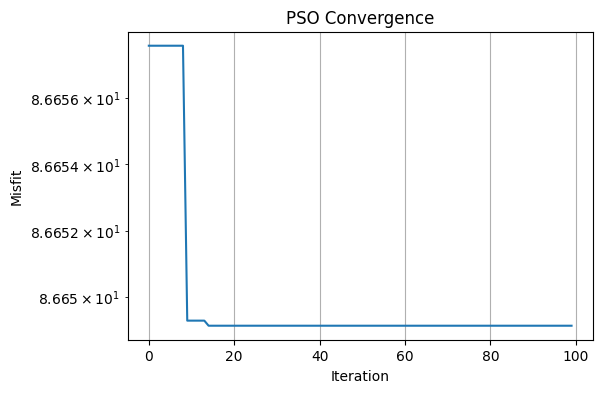

In [9]:
plt.figure(figsize=(6,4))
plt.semilogy(history)
plt.xlabel('Iteration')
plt.ylabel('Misfit')
plt.title('PSO Convergence')
plt.grid()
plt.show()


## Fitting Data

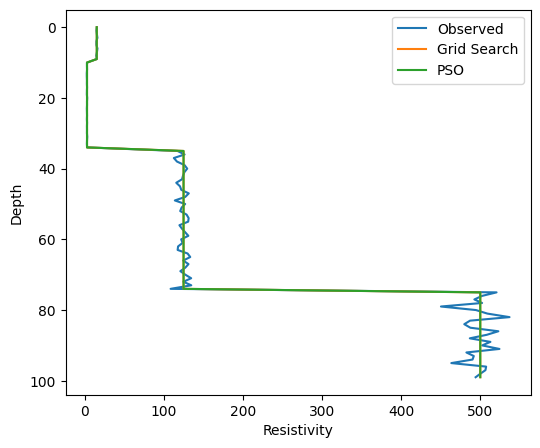

In [10]:
d_grid = forward_model(best_model_grid,depth)

d_pso = forward_model(
    [gbest[0],gbest[1],3,25,125,40,500],
    depth
)

plt.figure(figsize=(6,5))

plt.plot(d_obs,depth,label='Observed')
plt.plot(d_grid,depth,label='Grid Search')
plt.plot(d_pso,depth,label='PSO')

plt.gca().invert_yaxis()

plt.xlabel('Resistivity')
plt.ylabel('Depth')

plt.legend()

plt.show()


## Perbandingan Grid Search dan PSO

In [11]:
print('GRID SEARCH')
print('Misfit =',best_misfit_grid)
print('Time =',grid_time)

print('\nPSO')
print('Misfit =',gbest_cost)
print('Time =',pso_time)


GRID SEARCH
Misfit = 86.68027637597054
Time = 0.06918144226074219

PSO
Misfit = 86.64913288871404
Time = 0.3415646553039551


## Interpretasi Geologi

- Lapisan 1 (~15 ohm.m): alluvium atau sedimen jenuh air
- Lapisan 2 (~3 ohm.m): shale/lempung konduktif
- Lapisan 3 (~125 ohm.m): sandstone atau reservoir potensial
- Lapisan 4 (~500 ohm.m): basement kristalin resistif

Notebook ini dapat dikembangkan menjadi inversi 7 parameter penuh sesuai esai.
